<a href="https://colab.research.google.com/github/Ishank2301/CodeAlpha-HandwrittenCharacterRecognition/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Important Libraries:

In [30]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, MaxPooling2D, Conv2D, Dropout, Flatten

# Import the data or Download it:

In [31]:
# As we know collab provides important dataset such as MNIST, ResNet etc to be downloaded Directly.
# SO we can use some line of code to download them directly.
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


# Let's observe our data:

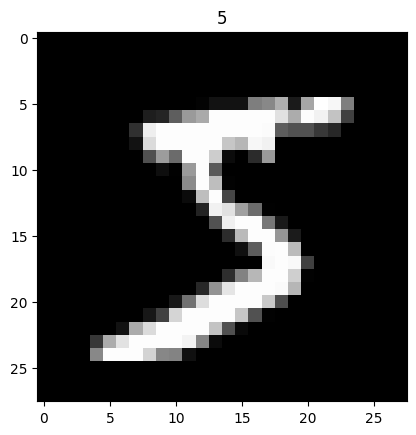

In [32]:

plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.show()

**As we can see this is how our data looks likes next we will try to adjust the imagw setting for our CNN model before building an CNN model so that we can achieve the highest accuracy and confidence**



**Reshape images to add the 1 channel (grayscale) and normalize pixels to [0, 1]**


In [33]:
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Building the model:

In [34]:
def my_model():
  model = Sequential([
      Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
      MaxPooling2D((2,2)),
      Conv2D(64,(3,3),activation='relu'),
      MaxPooling2D((2,2)),
      Flatten(),
      Dense(128,activation='relu'),
      Dense(10,activation='softmax'),
  ])

  return model
model  = my_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [41]:
# We will use early stopping to save computation and achieve best reults:
from tensorflow.keras.callbacks import EarlyStopping
cbks = EarlyStopping(
    monitor ='val_loss',
    patience = 3,
    restore_best_weights = True,
    verbose=1,
)

In [42]:
history = model.fit(X_train,y_train, validation_split=0.2, epochs=20,callbacks = cbks, batch_size=32)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.9555 - loss: 0.1454 - val_accuracy: 0.9844 - val_loss: 0.0505
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9851 - loss: 0.0488 - val_accuracy: 0.9867 - val_loss: 0.0447
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 42ms/step - accuracy: 0.9896 - loss: 0.0324 - val_accuracy: 0.9898 - val_loss: 0.0339
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 74s 50ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9893 - val_loss: 0.0407
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 47ms/step - accuracy: 0.9941 - loss: 0.0178 - val_accuracy: 0.9884 - val_loss: 0.0469
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9960 - loss: 0.0123 - val_accuracy: 0.9883 - val_loss: 0.0436
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


# Evaluate on test data:

In [43]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9903 - loss: 0.0297
Test Loss: 0.0297
Test Accuracy: 0.9903


# Make Predictions:

In [44]:
y_pred_probs = model.predict(X_test)

y_pred = y_pred_probs.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [45]:

print(y_pred[:10])
print(y_test[:10])

[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


# Visualize Predictions:

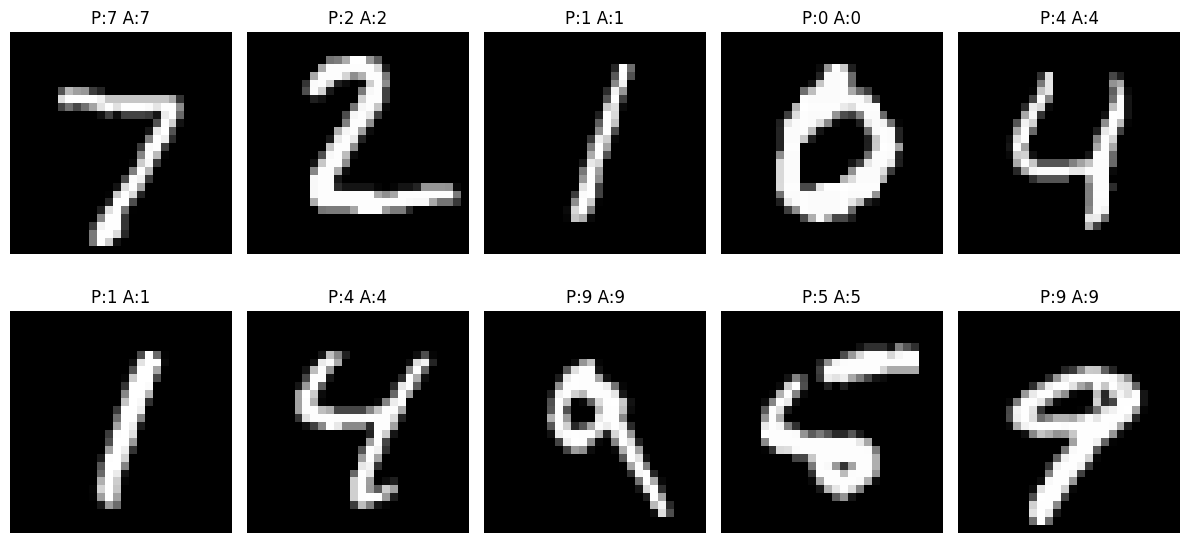

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"P:{y_pred[i]} A:{y_test[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Building a Confusion Matrix:

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 977    1    0    0    0    0    1    1    0    0]
 [   0 1131    0    1    0    1    2    0    0    0]
 [   1    1 1021    1    0    0    0    7    1    0]
 [   0    1    0 1003    0    4    0    0    2    0]
 [   0    0    0    0  981    0    0    1    0    0]
 [   1    0    0    5    0  883    1    1    0    1]
 [   3    2    0    0    1    3  947    0    2    0]
 [   0    3    1    2    1    0    0 1019    0    2]
 [   2    0    2    1    0    2    0    2  964    1]
 [   0    3    0    1    7    5    0    8    8  977]]


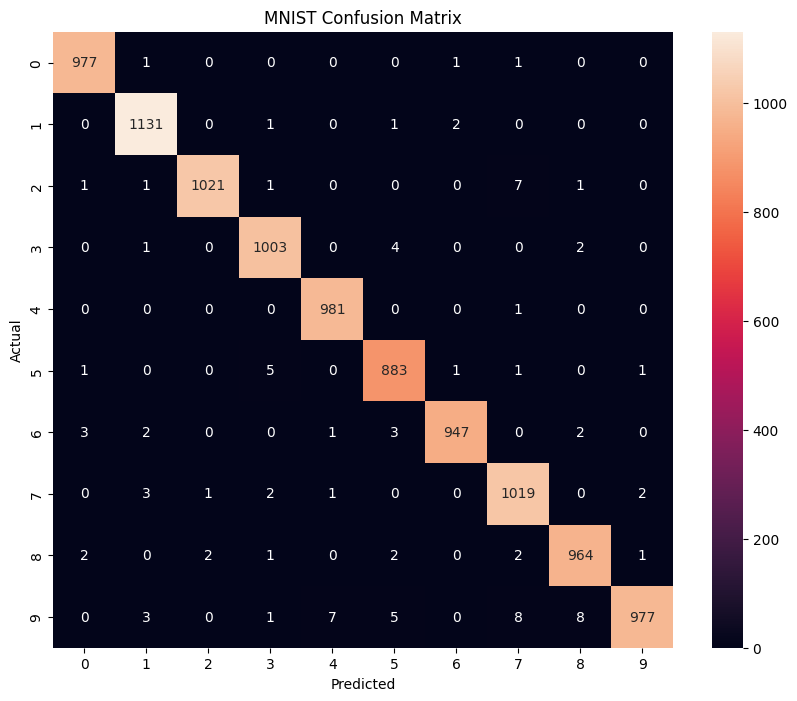

In [48]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")

plt.show()

# Benchmarks Testing:

In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



# Check for Errors:

In [50]:
wrong = np.where(
    y_pred != y_test
)[0]

print(
    "Wrong Predictions:",
    len(wrong)
)

Wrong Predictions: 97


# Display  Mistakes:

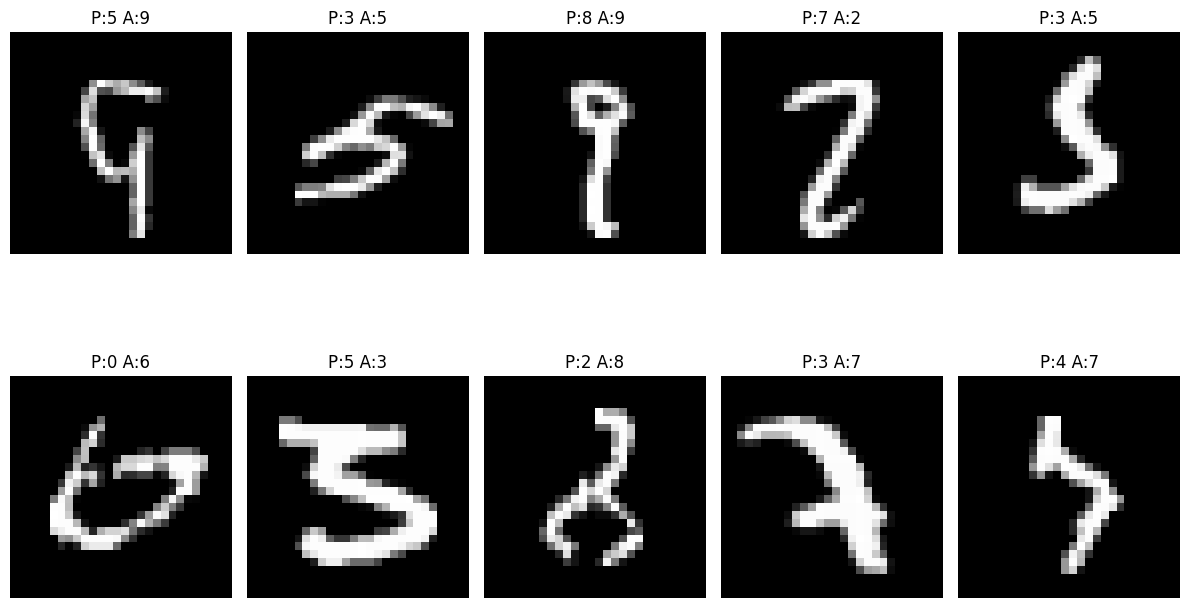

In [51]:
plt.figure(figsize=(12,8))

for i in range(10):

    idx = wrong[i]

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"P:{y_pred[idx]} A:{y_test[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Save and Download the model:

In [52]:
model.save("mnist_cnn.keras")

from google.colab import files

files.download(
    "mnist_cnn.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>